# Notebook 11 — Remaining Time Prediction

Predict how many days remain in a case after observing the first k events.

**Key difference from Notebook 07 (classification):**
- Target: `remaining_days = total_duration − elapsed_days_at_k` (regression, not binary)
- `elapsed_days` is **not leaky here** — it tells the model how fast the case has moved so far, which is genuine signal for predicting what's left
- Metric: MAE in days (interpretable for operations teams)
- Uncertainty: quantile regression at P10/P50/P90 — gives a range, not just a point estimate

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

ROOT         = Path.cwd().parent
T            = ROOT / 'outputs' / 'tables'
OUT          = ROOT / 'outputs' / 'figures'
RANDOM_STATE = 42
PREFIX_K     = 8

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
from src.load_event_log import load_xes_log

log = load_xes_log(ROOT / 'data' / 'raw' / 'PermitLog.xes', legacy=True)
rows = []
for trace in log:
    cid    = trace.attributes.get('concept:name', '')
    dept   = trace.attributes.get('case:OrganizationalEntity', '')
    budget = trace.attributes.get('case:RequestedBudget', np.nan)
    for evt in trace:
        rows.append({
            'case_id':   cid,
            'activity':  str(evt['concept:name']),
            'timestamp': evt['time:timestamp'],
            'org':       str(evt.get('org:resource', '')),
            'dept':      dept,
            'budget':    budget,
        })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

case_starts = df.groupby('case_id')['timestamp'].min()
case_ends   = df.groupby('case_id')['timestamp'].max()
total_dur   = (case_ends - case_starts).dt.total_seconds() / 86400

print(f'{len(df):,} events  |  {df.case_id.nunique():,} cases')
print(f'Total duration — median: {total_dur.median():.1f}d  mean: {total_dur.mean():.1f}d  max: {total_dur.max():.1f}d')

parsing log, completed traces ::   0%|          | 0/7065 [00:00<?, ?it/s]

parsing log, completed traces ::  15%|█▌        | 1081/7065 [00:00<00:00, 10783.25it/s]

parsing log, completed traces ::  31%|███       | 2160/7065 [00:00<00:00, 9834.95it/s] 

parsing log, completed traces ::  45%|████▍     | 3149/7065 [00:00<00:00, 9282.29it/s]

parsing log, completed traces ::  58%|█████▊    | 4082/7065 [00:00<00:00, 9149.49it/s]

parsing log, completed traces ::  71%|███████   | 4999/7065 [00:00<00:00, 8995.69it/s]

parsing log, completed traces ::  84%|████████▎ | 5900/7065 [00:00<00:00, 8891.57it/s]

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 9496.39it/s]

86,581 events  |  7,065 cases
Total duration — median: 71.7d  mean: 87.4d  max: 1190.3d


In [3]:
act_enc = LabelEncoder().fit(df['activity'])

ACTS = [
    'Send Reminder', 'Declaration REJECTED by DIRECTOR',
    'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by BUDGET OWNER',
    'Permit REJECTED by ADMINISTRATION', 'Permit REJECTED by BUDGET OWNER',
    'Permit REJECTED by PRE_APPROVER', 'Permit REJECTED by DIRECTOR',
    'Permit REJECTED by MISSING', 'Declaration APPROVED by DIRECTOR',
    'Declaration APPROVED by BUDGET OWNER', 'Declaration APPROVED by SUPERVISOR',
    'Permit APPROVED by BUDGET OWNER', 'Permit APPROVED by PRE_APPROVER',
    'Permit FINAL_APPROVED by SUPERVISOR',
]
flag_cols = [f"has_{a.replace(' ', '_').replace(':', '_')}" for a in ACTS]

def make_remaining_features(df, k):
    rows = []
    for cid, grp in df.groupby('case_id'):
        prefix  = grp.head(k)
        t0      = prefix['timestamp'].iloc[0]
        t_last  = prefix['timestamp'].iloc[-1]
        elapsed = (t_last - t0).total_seconds() / 86400
        total   = total_dur.get(cid, np.nan)
        remaining = total - elapsed

        feats = {
            'case_id':          cid,
            'elapsed_days':     elapsed,          # legitimate for regression
            'n_events_prefix':  len(prefix),
            'n_rejections':     prefix['activity'].str.contains('REJECTED').sum(),
            'n_reminders':      (prefix['activity'] == 'Send Reminder').sum(),
            'n_approvals':      prefix['activity'].str.contains('APPROVED').sum(),
            'first_act_enc':    act_enc.transform([prefix['activity'].iloc[0]])[0],
            'last_act_enc':     act_enc.transform([prefix['activity'].iloc[-1]])[0],
            'org_encoded':      hash(str(prefix['org'].iloc[-1])) % 1000,
            'budget':           prefix['budget'].iloc[0],
            'case_start_month': t0.month,
            'case_start_dow':   t0.dayofweek,
            'total_duration':   total,            # kept for reference, dropped before training
            'remaining_days':   remaining,        # TARGET
        }
        acts_in = set(prefix['activity'])
        for act, col in zip(ACTS, flag_cols):
            feats[col] = int(act in acts_in)
        rows.append(feats)
    return pd.DataFrame(rows)

feat_df = make_remaining_features(df, PREFIX_K)
feat_df = feat_df[feat_df['remaining_days'] >= 0].copy()   # drop right-censored edge cases

print(f'Feature matrix: {feat_df.shape}')
print(f'Remaining days — median: {feat_df["remaining_days"].median():.1f}d  '
      f'mean: {feat_df["remaining_days"].mean():.1f}d  '
      f'max: {feat_df["remaining_days"].max():.1f}d')
print(f'Cases with remaining > 0: {(feat_df["remaining_days"] > 0).sum():,}')

Feature matrix: (7065, 29)
Remaining days — median: 7.3d  mean: 23.5d  max: 681.4d
Cases with remaining > 0: 5,422


## MAE vs prefix length — how much earlier can we predict?

In [4]:
PREFIX_LENGTHS = [1, 3, 5, 8, 12, 20]
FEAT_COLS_BASE = ['elapsed_days', 'n_events_prefix', 'n_rejections', 'n_reminders',
                  'n_approvals', 'first_act_enc', 'last_act_enc', 'org_encoded',
                  'budget', 'case_start_month', 'case_start_dow'] + flag_cols

prefix_results = []
for k in PREFIX_LENGTHS:
    fdf = make_remaining_features(df, k)
    fdf = fdf[fdf['remaining_days'] >= 0].copy()

    feat_cols = [c for c in FEAT_COLS_BASE if c in fdf.columns]
    X = fdf[feat_cols]
    y = fdf['remaining_days'].values

    X = X.drop(columns=[c for c in X.columns if X[c].isna().all()])
    feat_cols = X.columns.tolist()

    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=feat_cols)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y, test_size=0.2, random_state=RANDOM_STATE)

    m = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          objective='reg:absoluteerror',
                          random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    baseline_mae = mean_absolute_error(y_te, np.full_like(y_te, y_tr.mean()))

    prefix_results.append({'k': k, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                            'baseline_MAE': baseline_mae})
    print(f'k={k:>2}  MAE={mae:.1f}d  RMSE={rmse:.1f}d  R²={r2:.3f}  '
          f'(baseline MAE={baseline_mae:.1f}d)')

pr_df = pd.DataFrame(prefix_results)
pr_df.to_csv(T / 'remaining_time_by_prefix.csv', index=False)

k= 1  MAE=44.5d  RMSE=66.5d  R²=-0.026  (baseline MAE=47.8d)


k= 3  MAE=40.6d  RMSE=60.7d  R²=0.044  (baseline MAE=46.0d)


k= 5  MAE=28.9d  RMSE=48.7d  R²=0.141  (baseline MAE=38.8d)


k= 8  MAE=12.4d  RMSE=33.3d  R²=0.415  (baseline MAE=26.6d)


k=12  MAE=6.3d  RMSE=25.7d  R²=0.313  (baseline MAE=14.2d)


k=20  MAE=1.7d  RMSE=14.7d  R²=0.306  (baseline MAE=4.0d)


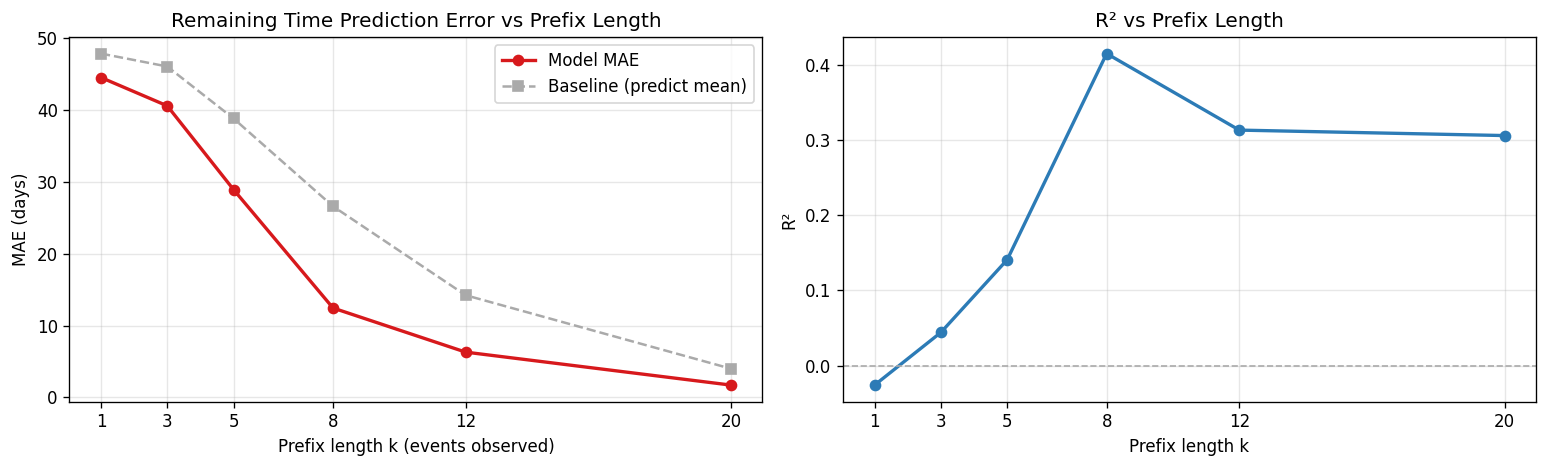

Saved remaining_time_mae_curve.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(pr_df['k'], pr_df['MAE'], 'o-', color='#d7191c', linewidth=2, label='Model MAE')
axes[0].plot(pr_df['k'], pr_df['baseline_MAE'], 's--', color='#aaaaaa',
             linewidth=1.5, label='Baseline (predict mean)')
axes[0].set_xlabel('Prefix length k (events observed)')
axes[0].set_ylabel('MAE (days)')
axes[0].set_title('Remaining Time Prediction Error vs Prefix Length')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(pr_df['k'])

axes[1].plot(pr_df['k'], pr_df['R2'], 'o-', color='#2c7bb6', linewidth=2)
axes[1].axhline(0, color='#aaaaaa', linewidth=1, linestyle='--', label='No skill')
axes[1].set_xlabel('Prefix length k')
axes[1].set_ylabel('R²')
axes[1].set_title('R² vs Prefix Length')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(pr_df['k'])

plt.tight_layout()
fig.savefig(OUT / 'remaining_time_mae_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved remaining_time_mae_curve.png')

## k=8 model: point predictions + temporal CV + SHAP

In [6]:
# Build final k=8 dataset
feat_df8 = make_remaining_features(df, PREFIX_K)
feat_df8 = feat_df8[feat_df8['remaining_days'] >= 0].copy()

feat_cols8 = [c for c in FEAT_COLS_BASE if c in feat_df8.columns]
X8 = feat_df8[feat_cols8].drop(columns=[c for c in feat_cols8 if feat_df8[c].isna().all()])
feat_cols8 = X8.columns.tolist()
y8 = feat_df8['remaining_days'].values

imp8 = SimpleImputer(strategy='median')
X8_imp = pd.DataFrame(imp8.fit_transform(X8), columns=feat_cols8)

X_tr8, X_te8, y_tr8, y_te8 = train_test_split(
    X8_imp, y8, test_size=0.2, random_state=RANDOM_STATE)

model8 = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:absoluteerror',
                            random_state=RANDOM_STATE, n_jobs=-1)
model8.fit(X_tr8, y_tr8)
y_pred8 = model8.predict(X_te8)

mae8  = mean_absolute_error(y_te8, y_pred8)
rmse8 = np.sqrt(mean_squared_error(y_te8, y_pred8))
r2_8  = r2_score(y_te8, y_pred8)
base8 = mean_absolute_error(y_te8, np.full_like(y_te8, y_tr8.mean()))

print(f'k=8 Remaining Time Model (80/20 split)')
print(f'  MAE:           {mae8:.1f} days')
print(f'  RMSE:          {rmse8:.1f} days')
print(f'  R²:            {r2_8:.3f}')
print(f'  Baseline MAE:  {base8:.1f} days  (predict training mean)')
print(f'  Skill (MAE):   {1 - mae8/base8:.1%}  reduction vs baseline')

k=8 Remaining Time Model (80/20 split)
  MAE:           12.4 days
  RMSE:          33.3 days
  R²:            0.415
  Baseline MAE:  26.6 days  (predict training mean)
  Skill (MAE):   53.2%  reduction vs baseline


In [7]:
# Temporal CV — expanding window (same folds as Notebook 08)
case_start_dates = feat_df8.set_index('case_id')['elapsed_days'] if False else \
    df.groupby('case_id')['timestamp'].min()

feat_df8['case_start'] = feat_df8['case_id'].map(case_start_dates)

TEMPORAL_FOLDS = [
    ('Q1 2018', pd.Timestamp('2018-01-01'), pd.Timestamp('2018-04-01')),
    ('Q2 2018', pd.Timestamp('2018-04-01'), pd.Timestamp('2018-07-01')),
    ('Q3 2018', pd.Timestamp('2018-07-01'), pd.Timestamp('2018-10-01')),
    ('Q4 2018', pd.Timestamp('2018-10-01'), pd.Timestamp('2019-01-01')),
]

tcv_results = []
for fold_name, test_start, test_end in TEMPORAL_FOLDS:
    train_mask = feat_df8['case_start'] < test_start
    test_mask  = (feat_df8['case_start'] >= test_start) & (feat_df8['case_start'] < test_end)

    if train_mask.sum() < 100 or test_mask.sum() < 10:
        continue

    Xtr = X8_imp[train_mask.values]
    Xte = X8_imp[test_mask.values]
    ytr = y8[train_mask.values]
    yte = y8[test_mask.values]

    imp_f = SimpleImputer(strategy='median')
    Xtr_f = pd.DataFrame(imp_f.fit_transform(Xtr), columns=feat_cols8)
    Xte_f = pd.DataFrame(imp_f.transform(Xte),     columns=feat_cols8)

    mf = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:absoluteerror',
                            random_state=RANDOM_STATE, n_jobs=-1)
    mf.fit(Xtr_f, ytr)
    ypred_f = mf.predict(Xte_f)

    mae_f  = mean_absolute_error(yte, ypred_f)
    rmse_f = np.sqrt(mean_squared_error(yte, ypred_f))
    r2_f   = r2_score(yte, ypred_f)
    base_f = mean_absolute_error(yte, np.full_like(yte, ytr.mean()))

    tcv_results.append({'fold': fold_name, 'n_train': train_mask.sum(),
                        'n_test': test_mask.sum(), 'MAE': mae_f,
                        'RMSE': rmse_f, 'R2': r2_f, 'baseline_MAE': base_f})
    print(f'{fold_name}  n_train={train_mask.sum():,}  n_test={test_mask.sum():,}  '
          f'MAE={mae_f:.1f}d  R²={r2_f:.3f}')

tcv_df = pd.DataFrame(tcv_results)
print(f'\nMean temporal CV MAE: {tcv_df["MAE"].mean():.1f}d')
print(f'Mean temporal CV R²:  {tcv_df["R2"].mean():.3f}')
tcv_df.to_csv(T / 'remaining_time_temporal_cv.csv', index=False)

Q1 2018  n_train=1,467  n_test=1,596  MAE=19.1d  R²=0.406


Q2 2018  n_train=3,063  n_test=1,713  MAE=12.5d  R²=0.517


Q3 2018  n_train=4,776  n_test=1,227  MAE=11.3d  R²=0.483


Q4 2018  n_train=6,003  n_test=1,062  MAE=7.9d  R²=0.471

Mean temporal CV MAE: 12.7d
Mean temporal CV R²:  0.469


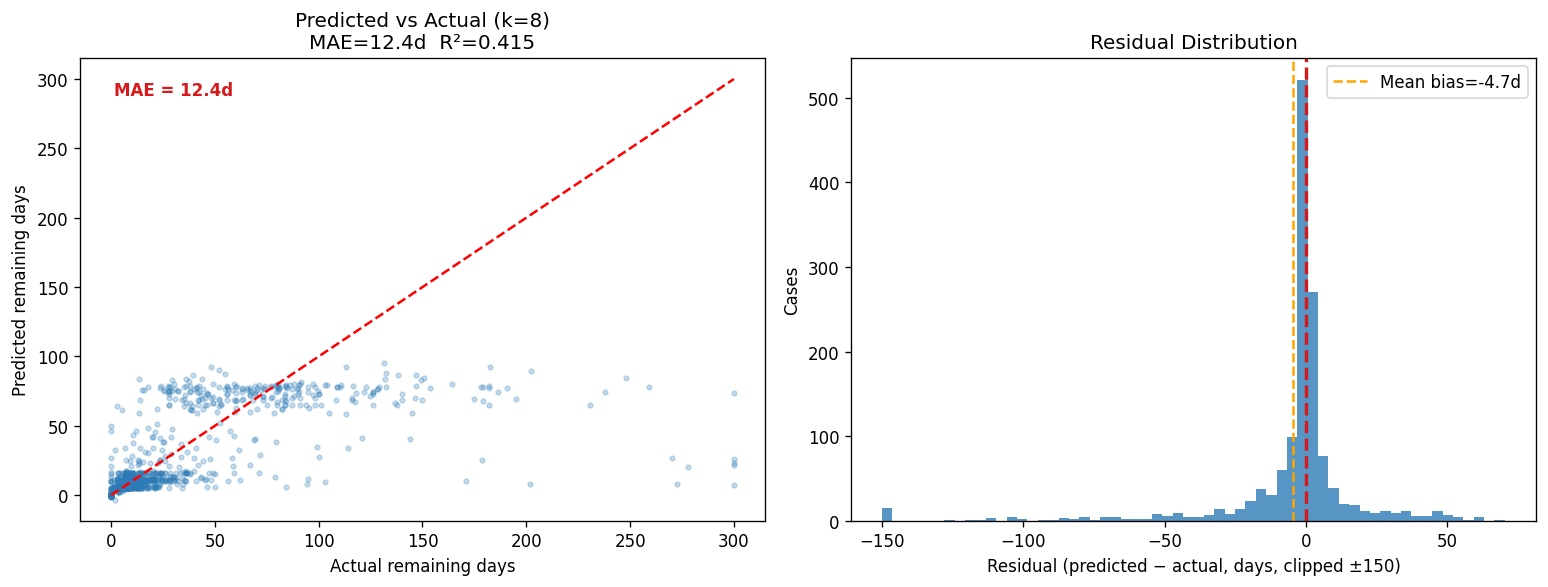

Saved remaining_time_pred_vs_actual.png


In [8]:
# Predicted vs actual + residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip = 300
axes[0].scatter(y_te8.clip(max=clip), y_pred8.clip(max=clip),
                alpha=0.25, s=8, color='#2c7bb6')
axes[0].plot([0, clip], [0, clip], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual remaining days')
axes[0].set_ylabel('Predicted remaining days')
axes[0].set_title(f'Predicted vs Actual (k=8)\nMAE={mae8:.1f}d  R²={r2_8:.3f}')
axes[0].text(0.05, 0.92, f'MAE = {mae8:.1f}d', transform=axes[0].transAxes,
             fontsize=10, color='#d7191c', fontweight='bold')

residuals = y_pred8 - y_te8
axes[1].hist(residuals.clip(-150, 150), bins=60, color='#2c7bb6', alpha=0.8)
axes[1].axvline(0, color='#d7191c', linewidth=2, linestyle='--')
axes[1].axvline(residuals.mean(), color='orange', linewidth=1.5,
                linestyle='--', label=f'Mean bias={residuals.mean():.1f}d')
axes[1].set_xlabel('Residual (predicted − actual, days, clipped ±150)')
axes[1].set_ylabel('Cases')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
fig.savefig(OUT / 'remaining_time_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved remaining_time_pred_vs_actual.png')

## Quantile regression — P10 / P50 / P90 prediction intervals

In [9]:
# Train three quantile models: P10, P50 (median), P90
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    m = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:quantileerror', quantile_alpha=q,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    m.fit(X_tr8, y_tr8)
    quantile_models[q] = m

p10 = quantile_models[0.1].predict(X_te8)
p50 = quantile_models[0.5].predict(X_te8)
p90 = quantile_models[0.9].predict(X_te8)

coverage      = np.mean((y_te8 >= p10) & (y_te8 <= p90))
interval_width = (p90 - p10).mean()

print(f'P10–P90 interval coverage: {coverage:.1%}  (target: 80%)')
print(f'Mean interval width:       {interval_width:.1f} days')
print(f'P50 MAE:                   {mean_absolute_error(y_te8, p50):.1f} days')

P10–P90 interval coverage: 80.8%  (target: 80%)
Mean interval width:       35.9 days
P50 MAE:                   12.4 days


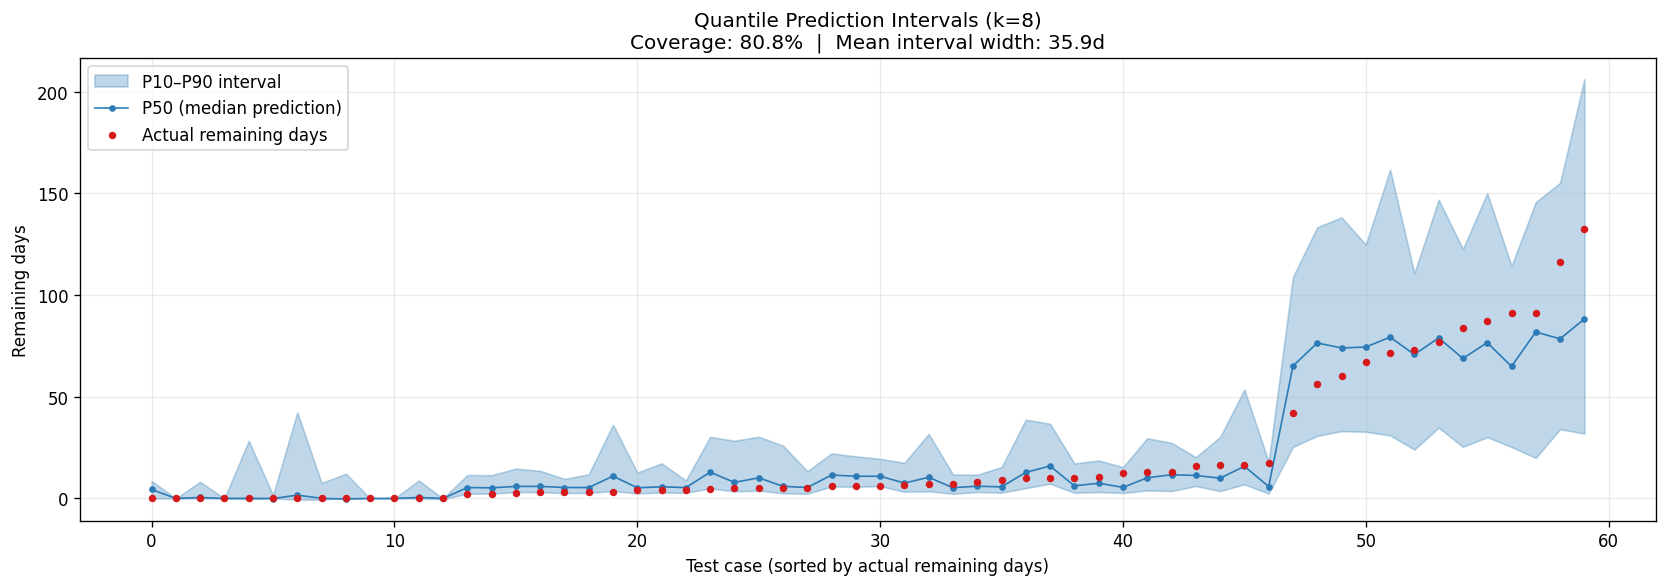

Saved remaining_time_quantile_intervals.png


In [10]:
# Plot prediction intervals on a random sample of 60 test cases
rng = np.random.default_rng(42)
idx = np.sort(rng.choice(len(y_te8), size=min(60, len(y_te8)), replace=False))

sort_order = np.argsort(y_te8[idx])
x_plot     = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(x_plot, p10[idx][sort_order], p90[idx][sort_order],
                alpha=0.3, color='#2c7bb6', label='P10–P90 interval')
ax.plot(x_plot, p50[idx][sort_order], 'o-', markersize=3, color='#2c7bb6',
        linewidth=1, label='P50 (median prediction)')
ax.scatter(x_plot, y_te8[idx][sort_order], s=12, color='#d7191c', zorder=5,
           label='Actual remaining days')
ax.set_xlabel('Test case (sorted by actual remaining days)')
ax.set_ylabel('Remaining days')
ax.set_title(f'Quantile Prediction Intervals (k=8)\n'
             f'Coverage: {coverage:.1%}  |  Mean interval width: {interval_width:.1f}d')
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
fig.savefig(OUT / 'remaining_time_quantile_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved remaining_time_quantile_intervals.png')

## SHAP — what drives remaining time estimates?

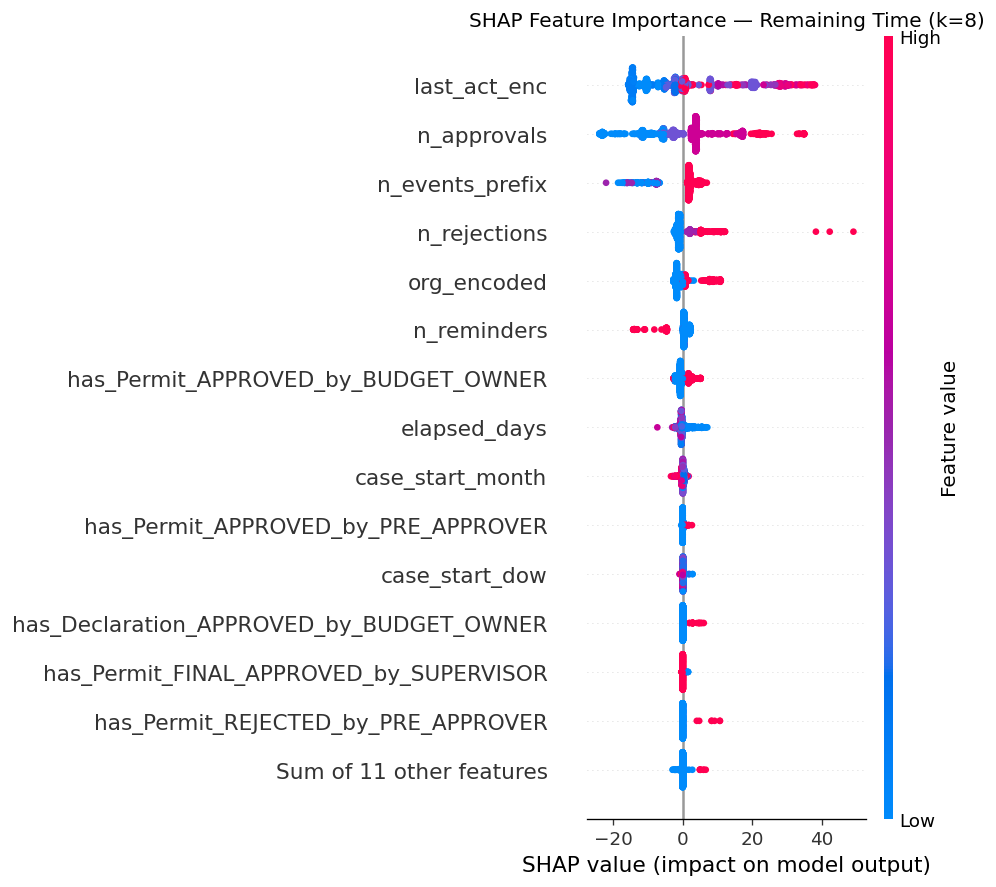

Saved remaining_time_shap_beeswarm.png


In [11]:
explainer8 = shap.TreeExplainer(model8)
shap_vals  = explainer8(X_te8)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(shap_vals, max_display=15, show=False)
ax.set_title('SHAP Feature Importance — Remaining Time (k=8)')
plt.tight_layout()
fig.savefig(OUT / 'remaining_time_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved remaining_time_shap_beeswarm.png')

## Save model + summary table

In [12]:
import joblib

bundle_reg = {
    "model_point":       model8,
    "model_p10":         quantile_models[0.1],
    "model_p50":         quantile_models[0.5],
    "model_p90":         quantile_models[0.9],
    "imputer":           imp8,
    "feature_cols":      feat_cols8,
    "mae_holdout":       round(float(mae8), 2),
    "r2_holdout":        round(float(r2_8), 3),
    "mae_temporal_cv":   round(float(tcv_df['MAE'].mean()), 2),
    "r2_temporal_cv":    round(float(tcv_df['R2'].mean()), 3),
    "coverage_p10_p90":  round(float(coverage), 3),
    "k":                 PREFIX_K,
    "note":              "elapsed_days IS included — not leaky for regression",
}
joblib.dump(bundle_reg, ROOT / 'app' / 'model' / 'remaining_time_k8.joblib')
print(f'Saved remaining_time_k8.joblib  ({(ROOT/"app"/"model"/"remaining_time_k8.joblib").stat().st_size // 1024} KB)')

summary = pd.DataFrame([{
    'metric':             'Remaining Time Prediction — k=8 (holdout)',
    'MAE (days)':         f'{mae8:.1f}',
    'RMSE (days)':        f'{rmse8:.1f}',
    'R2':                 f'{r2_8:.3f}',
    'baseline MAE':       f'{base8:.1f}',
    'MAE skill':          f'{1-mae8/base8:.1%}',
    'P10-P90 coverage':   f'{coverage:.1%}',
    'interval width (d)': f'{interval_width:.1f}',
}, {
    'metric':             'Remaining Time Prediction — k=8 (temporal CV mean)',
    'MAE (days)':         f'{tcv_df["MAE"].mean():.1f}',
    'RMSE (days)':        f'{tcv_df["RMSE"].mean():.1f}',
    'R2':                 f'{tcv_df["R2"].mean():.3f}',
    'baseline MAE':       '',
    'MAE skill':          '',
    'P10-P90 coverage':   '',
    'interval width (d)': '',
}])
summary.to_csv(T / 'remaining_time_summary.csv', index=False)
print('\nSummary:')
print(summary.to_string(index=False))

Saved remaining_time_k8.joblib  (1845 KB)

Summary:
                                            metric MAE (days) RMSE (days)    R2 baseline MAE MAE skill P10-P90 coverage interval width (d)
         Remaining Time Prediction — k=8 (holdout)       12.4        33.3 0.415         26.6     53.2%            80.8%               35.9
Remaining Time Prediction — k=8 (temporal CV mean)       12.7        29.6 0.469                                                           
